# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 25 - 3er bimestre 2026


## **Alumno:** Santiago Ruiz

Este tercer y último TP se debe entregar hasta las **23:59hs del martes 25 de agosto (hora de Argentina)**.

La resolución del TP se puede hacer en **parejas** o de forma **individual**.

Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/4gQ7iQQyJd2tn4Mb9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP3-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP3-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [1]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

#gdown.download(url, output, quiet=False)

#destino = "datos_zip"
#os.makedirs(destino, exist_ok=True)

#with zipfile.ZipFile(output, 'r') as zip_ref:
#    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = './datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = './datos_zip/dataset_emociones/validation'


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

# $$--- RESOLUCIÓN ---$$

## 1. Preprocesamiento de Datos

In [2]:
import os
import random
import copy
import time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


### 1.1 Exploración inicial del dataset

Se busca entender con qué datos se va a trabajar, para ello se determina cuántas imágenes hay por clase, de qué tamaño son, en qué formato de color viene y qué aspecto tienen.

In [3]:
CLASSES = sorted(os.listdir(DATASET_ROOT_TRAIN))
print("Clases encontradas:", CLASSES)

conteo_train = {c: len(os.listdir(os.path.join(DATASET_ROOT_TRAIN, c))) for c in CLASSES}
conteo_val   = {c: len(os.listdir(os.path.join(DATASET_ROOT_VAL, c)))   for c in CLASSES}

print("\nImágenes por clase (train):", conteo_train)
print("Imágenes por clase (validation):", conteo_val)
print("\nTotal train:", sum(conteo_train.values()))
print("Total validation:", sum(conteo_val.values()))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(CLASSES))
ax.bar(x - 0.2, [conteo_train[c] for c in CLASSES], width=0.4, label="train")
ax.bar(x + 0.2, [conteo_val[c] for c in CLASSES], width=0.4, label="validation")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30)
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de clases")
ax.legend()
plt.tight_layout()
plt.show()

Clases encontradas: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']

Imágenes por clase (train): {'alegria': 4772, 'disgusto': 717, 'enojo': 705, 'miedo': 281, 'seriedad': 2524, 'sorpresa': 1290, 'tristeza': 1982}
Imágenes por clase (validation): {'alegria': 1185, 'disgusto': 160, 'enojo': 162, 'miedo': 74, 'seriedad': 680, 'sorpresa': 329, 'tristeza': 478}

Total train: 12271
Total validation: 3068


<Figure size 900x400 with 1 Axes>

In [4]:
# Chequeo de tamaño y modo de color de una muestra de imágenes
tamaños, modos = set(), set()
for c in CLASSES:
    carpeta = os.path.join(DATASET_ROOT_TRAIN, c)
    for f in random.sample(os.listdir(carpeta), 10):
        img = Image.open(os.path.join(carpeta, f))
        tamaños.add(img.size)
        modos.add(img.mode)

print("Tamaños encontrados:", tamaños)
print("Modos de color encontrados:", modos)

Tamaños encontrados: {(100, 100)}
Modos de color encontrados: {'RGB'}


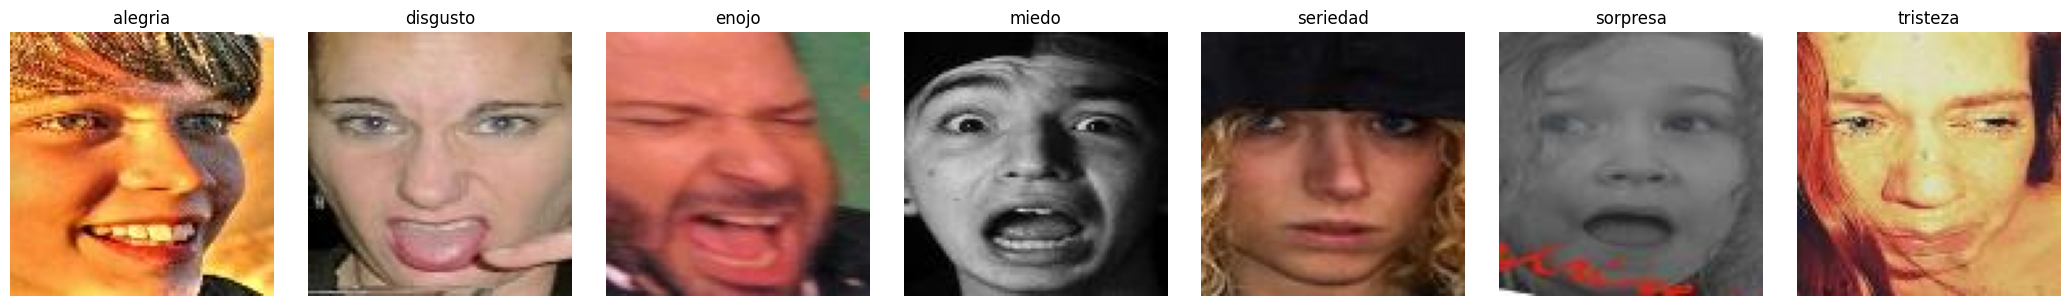

In [5]:
# Una imagen de ejemplo por clase
fig, axes = plt.subplots(1, len(CLASSES), figsize=(3 * len(CLASSES), 3))
for ax, c in zip(axes, CLASSES):
    carpeta = os.path.join(DATASET_ROOT_TRAIN, c)
    f = random.choice(os.listdir(carpeta))
    img = Image.open(os.path.join(carpeta, f))
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.tight_layout()
plt.show()

De la exploración anterior se desprenden dos observaciones clave:

1. **Todas las imágenes ya vienen alineadas y en 100x100 px, en color (RGB)** (nombre de archivo `..._aligned`). Esto significa que el trabajo de detección/alineación de rostro ya fue hecho por quien armó el dataset, así que no hace falta recortar ni alinear caras en esta etapa.
2. **El dataset está fuertemente desbalanceado**: `alegria` tiene ~4700 imágenes de entrenamiento mientras que `miedo` tiene apenas ~280. Si no se hace nada al respecto, el modelo va a tender a predecir siempre las clases mayoritarias.

En base a esto, las decisiones de preprocesamiento son:

- **Tamaño**: se reescalan las imágenes de 100x100 a **64x64**. Al ser rostros ya recortados y centrados, no se pierde información relevante para la tarea y se reduce el costo computacional (menos parámetros en las primeras capas convolucionales) sin resignar demasiado detalle facial.
- **Relación de aspecto**: no hace falta corregirla, todas las imágenes ya son cuadradas (100x100).
- **Color**: se mantiene el **color (RGB)** en lugar de pasar a escala de grises. Algunas emociones tienen componentes cromáticos útiles (enrojecimiento en enojo, palidez en miedo, brillo/lágrimas en tristeza) y el dataset ya viene en color, así que no hay motivo para descartar esa información.
- **Normalización**: se normaliza cada canal con la media y desvío estándar calculados sobre el propio training set (en vez de usar los valores típicos de ImageNet, que corresponden a otro dominio de imágenes).
- **Balanceo de clases**: en lugar de submuestrear la clase mayoritaria, lo que implicaría desperdiciar muchos datos, se usan **pesos por clase en la función de costo** (`CrossEntropyLoss(weight=...)`), inversamente proporcionales a la frecuencia de cada clase. Así los errores en clases minoritarias como `miedo` penalizan más que los errores en `alegria`.
- **Data augmentation** (solo en el conjunto de train): flip horizontal, rotaciones leves (±10°) y variaciones leves de brillo/contraste. Esto ayuda a que el modelo generalice mejor, en particular para las clases con pocos ejemplos, y actúa como regularización adicional.

In [6]:
# Media y desvío estándar del training set (sobre una muestra representativa,
# para no tener que cargar las ~12000 imágenes en memoria)
muestras = []
for c in CLASSES:
    carpeta = os.path.join(DATASET_ROOT_TRAIN, c)
    archivos = os.listdir(carpeta)
    for f in random.sample(archivos, min(200, len(archivos))):
        img = np.array(Image.open(os.path.join(carpeta, f)).convert("RGB")) / 255.0
        muestras.append(img.reshape(-1, 3))

muestras = np.concatenate(muestras, axis=0)
MEAN = muestras.mean(axis=0).tolist()
STD = muestras.std(axis=0).tolist()
print("Media por canal (RGB):", MEAN)
print("Desvío estándar por canal (RGB):", STD)

Media por canal (RGB): [0.5549090913130784, 0.44419185154990315, 0.39941443978834945]
Desvío estándar por canal (RGB): [0.2777264893963944, 0.2519322211804623, 0.24938239377051602]


In [7]:
IMG_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# En validation NO se aplica augmentation, solo el preprocesamiento base,
# para evaluar el modelo sobre datos "limpios"
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_dataset = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_ROOT_VAL, transform=val_transform)

print("Clases (idx -> nombre):", train_dataset.classes)
print("Cantidad train:", len(train_dataset))
print("Cantidad validation:", len(val_dataset))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Clases (idx -> nombre): ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Cantidad train: 12271
Cantidad validation: 3068


In [8]:
# Pesos por clase para compensar el desbalance en la función de costo
etiquetas_train = [label for _, label in train_dataset.samples]
conteo_por_idx = np.bincount(etiquetas_train)
class_weights = conteo_por_idx.sum() / (len(conteo_por_idx) * conteo_por_idx)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

for c, idx, w in zip(train_dataset.classes, range(len(class_weights)), class_weights):
    print(f"{c:10s} -> peso {w:.3f}")

alegria    -> peso 0.367
disgusto   -> peso 2.445
enojo      -> peso 2.487
miedo      -> peso 6.238
seriedad   -> peso 0.695
sorpresa   -> peso 1.359
tristeza   -> peso 0.884


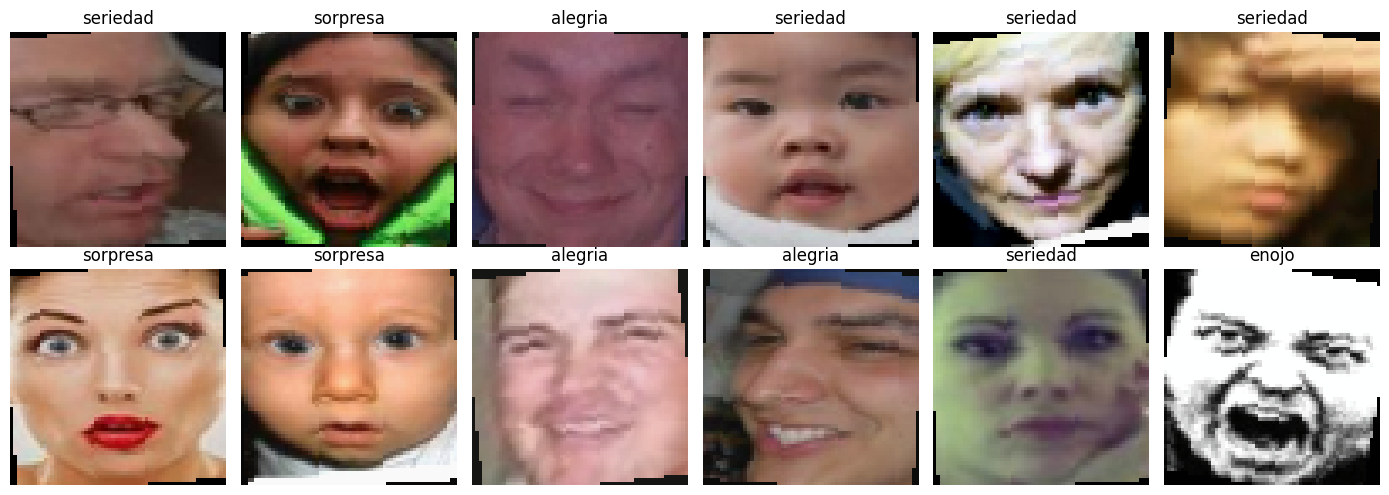

In [9]:
# Visualización de un batch ya preprocesado (con augmentation) para verificar
# que las transformaciones se aplican correctamente
def desnormalizar(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, img, label in zip(axes.flatten(), imgs[:12], labels[:12]):
    ax.imshow(desnormalizar(img))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Construcción y entrenamiento del Modelo CNN

### Arquitectura de la red

Se define una CNN desde cero, pensada para imágenes de 64x64
- **4 bloques convolucionales** (32 → 64 → 128 → 256 canales), cada uno con dos convoluciones 3x3, `BatchNorm2d` y activación `ReLU`, seguidos de `MaxPool2d(2)` y `Dropout(0.25)`.
  - Dos convoluciones por bloque (en vez de una) aumentan el campo receptivo sin agrandar demasiado el kernel.
  - `BatchNorm` estabiliza y acelera el entrenamiento, algo importante porque se está usando una loss ponderada por clase
  - `ReLU` se usa en todas las capas ocultas por ser simple, rápida de calcular y evitar el problema de gradientes que se desvanecen (a diferencia de sigmoid/tanh).
  - `Dropout` combate el sobreajuste, algo crítico acá porque hay clases con muy pocos ejemplos (`miedo` ≈ 280 imágenes).
- **`AdaptiveAvgPool2d(1)`** en vez de aplanar directamente el mapa de features: reduce drásticamente la cantidad de parámetros de la capa totalmente conectada (que si no, sería enorme y propensa a overfitting) y hace que la red no dependa de un tamaño de entrada fijo.
- **Cabezal totalmente conectado**: `Linear(256→128)` + `ReLU` + `Dropout(0.5)` + `Linear(128→7)`.
- La capa de salida entrega **logits crudos** (sin softmax explícito), porque `nn.CrossEntropyLoss` de PyTorch ya aplica `log_softmax` internamente de forma numéricamente más estable.


In [10]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def bloque_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2),
                nn.Dropout(0.25),
            )

        self.features = nn.Sequential(
            bloque_conv(3, 32),     # 64x64 -> 32x32
            bloque_conv(32, 64),    # 32x32 -> 16x16
            bloque_conv(64, 128),   # 16x16 -> 8x8
            bloque_conv(128, 256),  # 8x8   -> 4x4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


model = EmotionCNN(num_classes=len(CLASSES)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nCantidad de parámetros entrenables: {n_params:,}")

# Test rápido de forward pass con un batch de ejemplo
x_test, _ = next(iter(train_loader))
out_test = model(x_test.to(device))
print("Shape de salida del modelo:", out_test.shape)  # (batch, num_classes)

EmotionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_r

### Función de costo, optimizador y learning rate

- **Función de costo**: `CrossEntropyLoss` con `weight=class_weights_t` (los pesos por clase calculados en el punto 1), para que los errores en las clases minoritarias pesen más y el modelo no colapse prediciendo siempre `alegria`.
- **Optimizador**: `Adam`, porque adapta el learning rate por parámetro y converge más rápido y de forma más estable que SGD plano en redes convolucionales de este tamaño, sin necesitar mucho tuneo manual del learning rate.
- **Learning rate**: se parte de `1e-3` (valor estándar de partida para Adam) y se agrega `weight_decay=1e-4` (regularización L2) para ayudar a controlar el overfitting.
- **Scheduler**: `ReduceLROnPlateau`, que reduce el learning rate a la mitad si el loss de validación deja de mejorar durante algunas épocas. Esto permite afinar el entrenamiento en las últimas épocas sin tener que definir a mano un cronograma fijo de learning rate.
- **Early stopping + checkpoint del mejor modelo**: se guarda una copia de los pesos cada vez que mejora el loss de validación, y se detiene el entrenamiento si no hay mejoras durante varias épocas seguidas. Al final se restauran los mejores pesos encontrados (no necesariamente los de la última época) para la evaluación del punto 3.

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

N_EPOCHS = 40
PATIENCE_EARLY_STOP = 8


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1_macro

In [12]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1": [], "val_f1": [],
}

best_val_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())
epochs_sin_mejora = 0

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, train_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1

    print(f"Epoch {epoch:02d}/{N_EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
          f"train_f1={train_f1:.4f} val_f1={val_f1:.4f} | "
          f"{time.time() - t0:.1f}s")

    if epochs_sin_mejora >= PATIENCE_EARLY_STOP:
        print(f"\nEarly stopping en la época {epoch} (sin mejora en {PATIENCE_EARLY_STOP} épocas).")
        break

# Se restauran los pesos del mejor modelo (menor val_loss) para la evaluación
model.load_state_dict(best_model_weights)
print(f"\nMejor val_loss alcanzado: {best_val_loss:.4f}")

Epoch 01/40 | train_loss=1.9210 val_loss=1.8331 | train_acc=0.2338 val_acc=0.3530 | train_f1=0.1533 val_f1=0.1323 | 291.0s
Epoch 02/40 | train_loss=1.8837 val_loss=1.8703 | train_acc=0.2686 val_acc=0.3442 | train_f1=0.1568 val_f1=0.1456 | 275.9s
Epoch 03/40 | train_loss=1.8788 val_loss=1.8386 | train_acc=0.2600 val_acc=0.3132 | train_f1=0.1632 val_f1=0.1863 | 287.0s
Epoch 04/40 | train_loss=1.8620 val_loss=1.8786 | train_acc=0.2549 val_acc=0.2154 | train_f1=0.1678 val_f1=0.1347 | 293.5s
Epoch 05/40 | train_loss=1.8442 val_loss=1.7492 | train_acc=0.2570 val_acc=0.3706 | train_f1=0.1804 val_f1=0.1689 | 318.5s
Epoch 06/40 | train_loss=1.8329 val_loss=1.8046 | train_acc=0.2617 val_acc=0.3393 | train_f1=0.1799 val_f1=0.1882 | 297.1s
Epoch 07/40 | train_loss=1.8147 val_loss=1.8205 | train_acc=0.2372 val_acc=0.2669 | train_f1=0.1853 val_f1=0.2085 | 287.3s
Epoch 08/40 | train_loss=1.7759 val_loss=1.9780 | train_acc=0.2709 val_acc=0.2229 | train_f1=0.2126 val_f1=0.1559 | 273.1s
Epoch 09/40 | tr

## Evaluación del Modelo

### Curvas de entrenamiento: Loss, Accuracy y F1 Macro por época

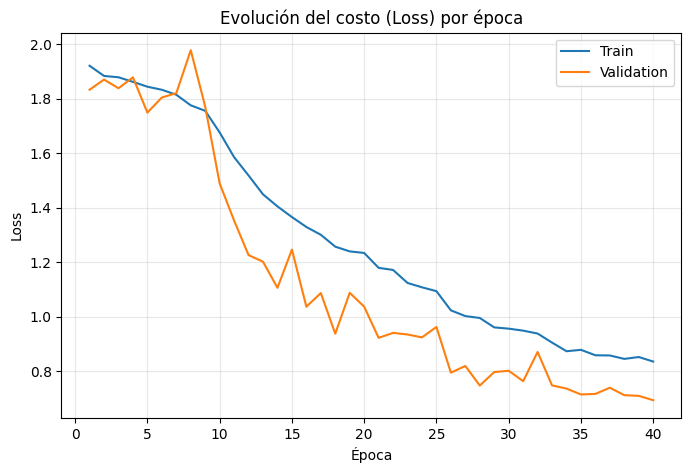

In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], label="Validation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución del costo (Loss) por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

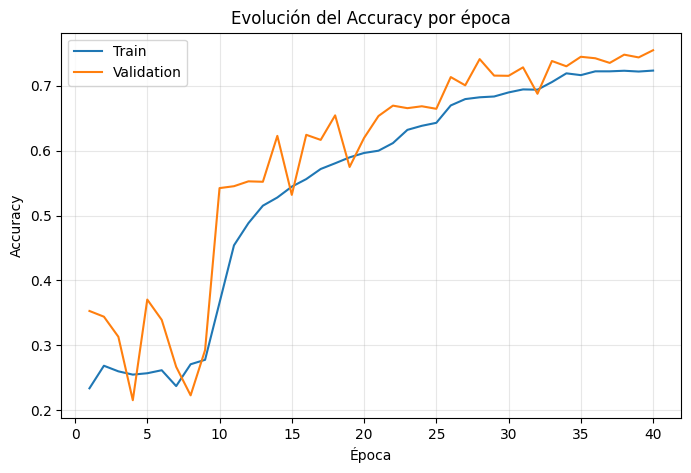

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train")
plt.plot(epochs_range, history["val_acc"], label="Validation")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución del Accuracy por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

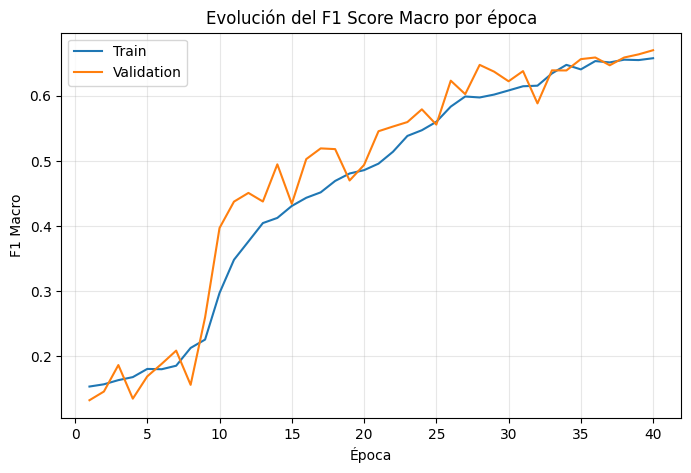

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_f1"], label="Train")
plt.plot(epochs_range, history["val_f1"], label="Validation")
plt.xlabel("Época")
plt.ylabel("F1 Macro")
plt.title("Evolución del F1 Score Macro por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Métricas sobre el conjunto de validación

Se utiliza el mejor modelo para calcular las métricas finales

In [16]:
val_loss_final, val_acc_final, val_f1_final = run_epoch(val_loader, train=False)

print(f"Accuracy final (validation): {val_acc_final:.4f}")
print(f"F1 Score Macro final (validation): {val_f1_final:.4f}")

Accuracy final (validation): 0.7549
F1 Score Macro final (validation): 0.6701


### Classification report

In [17]:
# Se recalculan las predicciones sobre todo el set de validación para el reporte
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

              precision    recall  f1-score   support

     alegria       0.94      0.86      0.89      1185
    disgusto       0.28      0.42      0.34       160
       enojo       0.69      0.69      0.69       162
       miedo       0.52      0.65      0.58        74
    seriedad       0.73      0.69      0.71       680
    sorpresa       0.75      0.86      0.80       329
    tristeza       0.69      0.67      0.68       478

    accuracy                           0.75      3068
   macro avg       0.66      0.69      0.67      3068
weighted avg       0.77      0.75      0.76      3068



### Matriz de confusión absoluta y normalizada

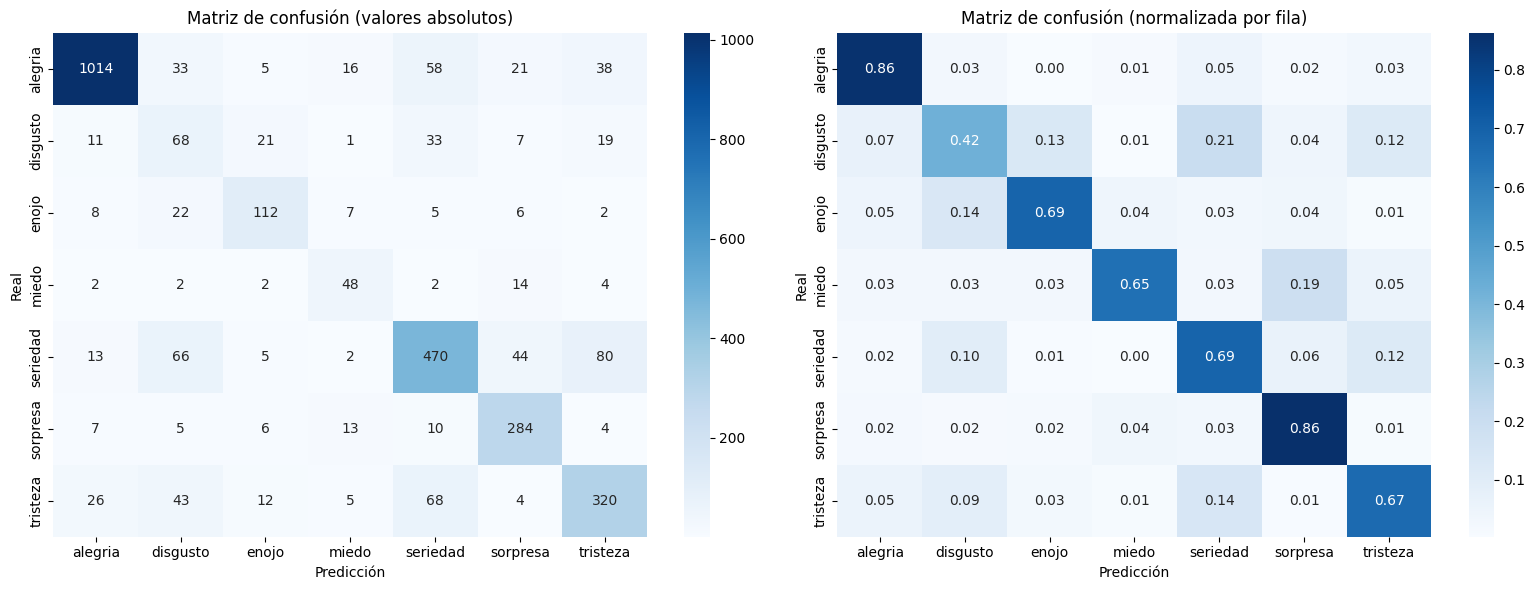

In [18]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalizada = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Matriz de confusión (valores absolutos)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(cm_normalizada, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("Matriz de confusión (normalizada por fila)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()